X_test shape: (4000, 63)
Feature names: 63
Sample of feature names: ['Age', 'Dependents', 'City_Tier', 'Years_at_Current_Job', 'Total_Work_Experience', 'Annual_Income', 'Other_Income', 'Existing_Loans', 'Existing_Loan_Amount', 'Monthly_EMI']

Computing SHAP values...
SHAP values shape: (500, 63)


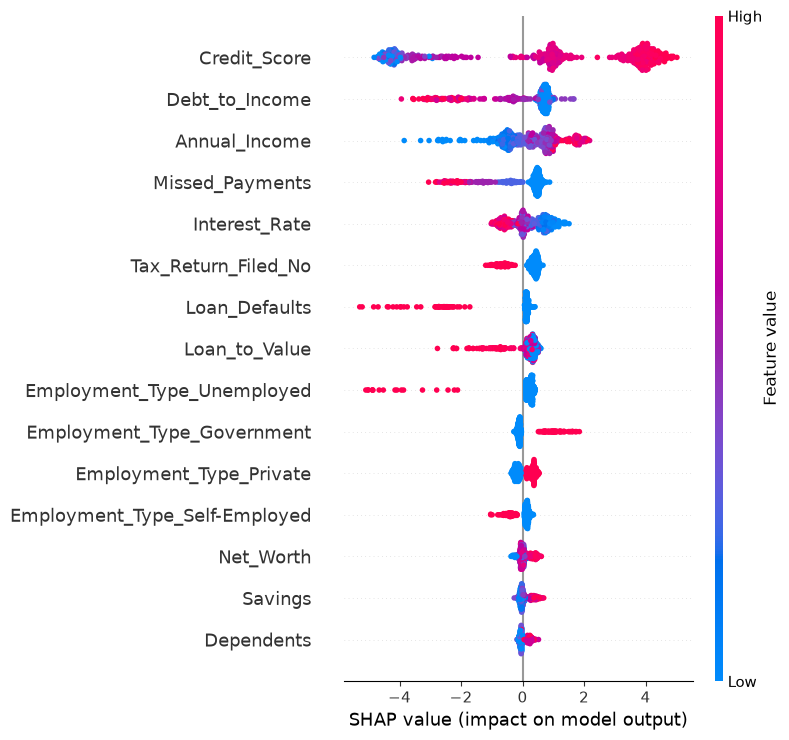


✅ SHAP summary plot saved.


In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import shap
import matplotlib.pyplot as plt

BASE = r'C:\Users\Anushka Thite\Desktop\smart-loan-system'
PROCESSED_DIR = os.path.join(BASE, 'data', 'processed')
MODELS_DIR = os.path.join(BASE, 'models')

X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
feature_names = joblib.load(os.path.join(MODELS_DIR, 'feature_names.pkl'))

# Load the stacking model — extract XGBoost for SHAP
stack = joblib.load(os.path.join(MODELS_DIR, 'stacking.pkl'))
xgb_model = stack.named_estimators_['xgb']

print(f"X_test shape: {X_test.shape}")
print(f"Feature names: {len(feature_names)}")
print(f"Sample of feature names: {feature_names[:10]}")

# SHAP on XGBoost (fast, tree-based)
print("\nComputing SHAP values...")
explainer = shap.TreeExplainer(xgb_model)

# Use 500 samples for speed
sample = X_test[:500]
shap_values = explainer.shap_values(sample)
print(f"SHAP values shape: {shap_values.shape}")

# Save for later
np.save(os.path.join(MODELS_DIR, 'shap_values.npy'), shap_values)
np.save(os.path.join(MODELS_DIR, 'shap_sample.npy'), sample)

# Global summary plot
plt.figure()
shap.summary_plot(shap_values, sample, feature_names=feature_names, show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'shap_summary.png'), dpi=100, bbox_inches='tight')
plt.show()
print("\n✅ SHAP summary plot saved.")

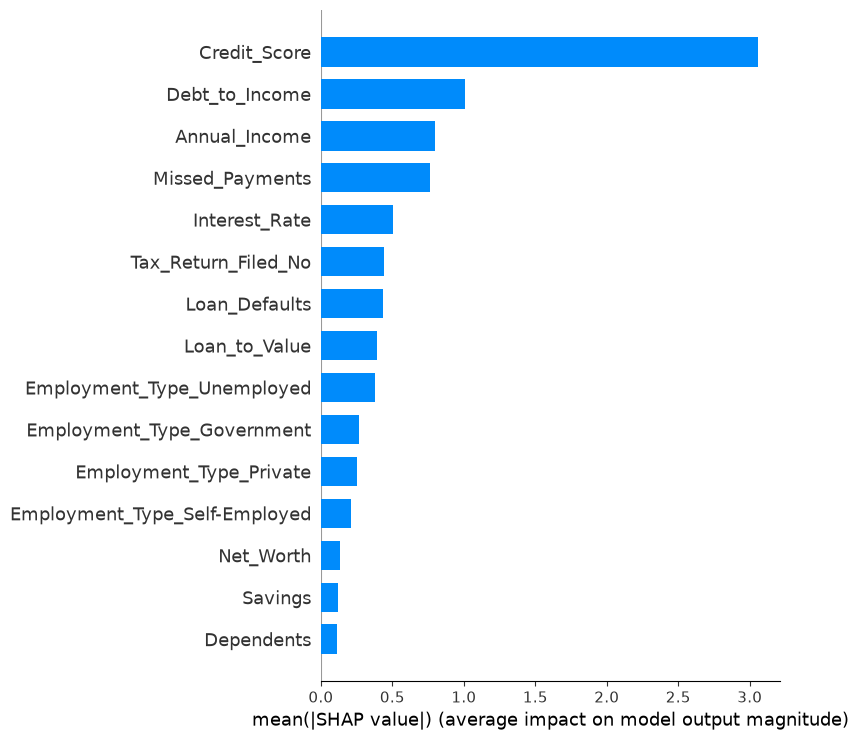

Top 15 features by mean |SHAP|:
                      Feature  Mean_Abs_SHAP
                 Credit_Score       3.058634
               Debt_to_Income       1.011118
                Annual_Income       0.797974
              Missed_Payments       0.762203
                Interest_Rate       0.505703
          Tax_Return_Filed_No       0.438112
                Loan_Defaults       0.435807
                Loan_to_Value       0.390027
   Employment_Type_Unemployed       0.381315
   Employment_Type_Government       0.266306
      Employment_Type_Private       0.251484
Employment_Type_Self-Employed       0.209011
                    Net_Worth       0.135575
                      Savings       0.121250
                   Dependents       0.111576

✅ Saved: shap_bar.png, shap_importance.csv


In [2]:
import matplotlib.pyplot as plt
import shap
import numpy as np
import joblib
import os

BASE = r'C:\Users\Anushka Thite\Desktop\smart-loan-system'
MODELS_DIR = os.path.join(BASE, 'models')

shap_values = np.load(os.path.join(MODELS_DIR, 'shap_values.npy'))
sample = np.load(os.path.join(MODELS_DIR, 'shap_sample.npy'))
feature_names = joblib.load(os.path.join(MODELS_DIR, 'feature_names.pkl'))

# Bar plot — cleaner top-15 view
plt.figure()
shap.summary_plot(shap_values, sample, feature_names=feature_names,
                  plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'shap_bar.png'), dpi=100, bbox_inches='tight')
plt.show()

# Save as text — for report
import pandas as pd
mean_abs = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 15 features by mean |SHAP|:")
print(importance_df.head(15).to_string(index=False))

importance_df.to_csv(os.path.join(MODELS_DIR, 'shap_importance.csv'), index=False)
print("\n✅ Saved: shap_bar.png, shap_importance.csv")

In [3]:
import shap
import numpy as np
import joblib
import os

BASE = r'C:\Users\Anushka Thite\Desktop\smart-loan-system'
PROCESSED_DIR = os.path.join(BASE, 'data', 'processed')
MODELS_DIR = os.path.join(BASE, 'models')

X_test = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))
feature_names = joblib.load(os.path.join(MODELS_DIR, 'feature_names.pkl'))
stack = joblib.load(os.path.join(MODELS_DIR, 'stacking.pkl'))
xgb_model = stack.named_estimators_['xgb']

# Find one rejected applicant
rejected_indices = np.where(y_test == 0)[0]
idx = rejected_indices[0]

explainer = shap.TreeExplainer(xgb_model)
single_shap = explainer.shap_values(X_test[idx:idx+1])

pred = stack.predict(X_test[idx:idx+1])[0]
proba = stack.predict_proba(X_test[idx:idx+1])[0, 1]

print(f"Applicant index: {idx}")
print(f"Actual label: Rejected")
print(f"Model prediction: {'Approved' if pred == 1 else 'Rejected'} (probability: {proba:.4f})")
print()

contributions = list(zip(feature_names, single_shap[0]))
contributions.sort(key=lambda x: abs(x[1]), reverse=True)

print("Top 10 factors influencing this decision:")
print("-" * 65)
for feat, val in contributions[:10]:
    direction = "→ APPROVE ✅" if val > 0 else "→ REJECT ❌"
    print(f"  {feat:42s} {val:+.4f}  {direction}")

Applicant index: 3
Actual label: Rejected
Model prediction: Rejected (probability: 0.0068)

Top 10 factors influencing this decision:
-----------------------------------------------------------------
  Credit_Score                               -4.2708  → REJECT ❌
  Loan_Defaults                              -2.2368  → REJECT ❌
  Debt_to_Income                             -2.0649  → REJECT ❌
  Missed_Payments                            -1.0530  → REJECT ❌
  Loan_to_Value                              -0.7259  → REJECT ❌
  Interest_Rate                              -0.7231  → REJECT ❌
  Annual_Income                              -0.5926  → REJECT ❌
  Tax_Return_Filed_No                        -0.5568  → REJECT ❌
  Total_Work_Experience                      +0.1510  → APPROVE ✅
  Employment_Type_Private                    +0.1306  → APPROVE ✅
